### Задача 1

Импортируйте файл Event_click.xlsx.\
В нем содержатся результаты A/B теста, который проводился в онлайн-кинотеатре. В рамках эксперимента тестировалась новая рекомендательная система, цель которой - убедить пользователя просмотреть тот или иной тайтл.\

Описание данных:
- id_client - уникальный идентификатор клиента
- dtime_event - дата совершения события (временная часть опущена для облегчения данных)
- flag_group - флаг принадлежности к тестовой группе (1 - тест, 0 -контроль).
- event - залогированное клиентское событие (play - пригрывание плеера, click - клик мышкой, scroll - прокручивание страницы)

Необходимо подготовить данные к анализу результатов A/B теста.\
Для этого:
1. Определите количество нуллов в рамках каждого столбца (и их пересечений) и исключите все записи, в которых отсутствует информация хотя бы в одном поле.
2. Выявите клиентов, которые в течение эксперимента попадали в разные группы (*Подсказка: рассчитайте количество уникальных значений поля flag_group на каждого клиента*)
3. Исключите этих клиентов из выборки.
4. Оцените общее количество исключений (относительно всей выборки)


In [1]:
import pandas as pd
from IPython.display import display
from matplotlib import pyplot as plt
import numpy as np
from scipy.stats import ttest_ind

In [3]:
df = pd.read_excel('Event_click.xlsx')
cnt_null = df.isnull().sum()
print("Количество пропусков по столбцам:\n", cnt_null)

df_clean = df.dropna()

cl_gr = df_clean.groupby('id_client')['flag_group'].nunique()


cl_mul_gr = cl_gr[cl_gr > 1].index


df_final = df_clean[~df_clean['id_client'].isin(cl_mul_gr)]

excluded_rows = len(df) - len(df_final)
total_rows = len(df)
percentage_excluded = (excluded_rows / total_rows) * 100

print(f"Общее количество исключённых записей: {excluded_rows}")
print(f"Процент исключённых записей относительно всей выборки: {percentage_excluded:.2f}%")

Количество пропусков по столбцам:
 id_client       94
dtime_event      0
flag_group     392
event          513
dtype: int64
Общее количество исключённых записей: 778
Процент исключённых записей относительно всей выборки: 7.37%


## Задача 2

Задача новой рекомендательной системы заключается в том, чтобы повысить процент людей, которые при заходе на нашу страницу (то есть при совершении любого действия) перейдут в плеер (то есть совершат действие play).

Рассчитайте отдельно для *контрольной* и *тестовой* группы процент пользователей, которые совершили хотя бы одно действие play. Можете ли вы сделать вывод о значимом улучшении конверсии в просмотр?

Обратите внимание, что в Задании 2 мы работаем с очищенными данными, полученными в результате выполнения Задания 1.

Алгоритм решения:

+ создайте в данных новую колонку flag_play, которая принимает значение 1, если совершаемое действие - ‘play’ и 0 для любого другого действия


+ сгруппируйте данные по двум столбцам одновременно - пользователь и его группа - и посчитайте максимальное значение по колонке flag_play (если пользователь хотя бы раз играл, то максимальное значение будет 1, если ни разу, то окажется 0), назовем его max_flag


+ возьмите среднее значение max_flag  для тестовой и контрольной групп - отличаются ли значения?


+ проведите t-тест по колонке max_flag для тестовой и контрольной групп, чтобы оценить стат. значимость разницы в средних значениях между ними. Воспользуйтесь функцией ttest_ind.

In [5]:
df_final = df_final.copy()
df_final['flag_play'] = np.where(df_final['event'] == 'play', 1, 0)
max_flag = df_final.groupby(['id_client', 'flag_group'])['flag_play'].max().reset_index()
mean_control = max_flag[max_flag['flag_group'] == 0]['flag_play'].mean()
mean_test = max_flag[max_flag['flag_group'] == 1]['flag_play'].mean()
print(f"Процент пользователей в контрольной группе, совершивших хотя бы одно 'play': {mean_control * 100:.2f}%")
print(f"Процент пользователей в тестовой группе, совершивших хотя бы одно 'play': {mean_test * 100:.2f}%")


control_values = max_flag[max_flag['flag_group'] == 0]['flag_play']
test_values = max_flag[max_flag['flag_group'] == 1]['flag_play']

t_stat, p_value = ttest_ind(control_values, test_values, equal_var=False)

print(f"T-статистика: {t_stat:.4f}")
print(f"P-значение: {p_value:.4f}")

# Итоговая интерпретация:
#Разница в долях пользователей, совершивших 'play', между тестовой и контрольной группами — статистически значима.
#В тестовой группе процент пользователей, совершивших 'play', выше, чем в контрольной.
#Вероятность того, что такая разница возникла случайно — менее 1%.
#Вывод:
#Можно с уверенностью сказать, что внедренное изменение или эксперимент оказали положительный эффект — увеличили активность пользователей по сравнению с контрольной группой.



Процент пользователей в контрольной группе, совершивших хотя бы одно 'play': 28.33%
Процент пользователей в тестовой группе, совершивших хотя бы одно 'play': 31.47%
T-статистика: -2.6556
P-значение: 0.0079


## Задача 3

Рассчитайте DAU и WAU по имеющимся данным.\
Допустим, активностью пользователя является любая активность (совершение любого действия, хотя бы одного).\

1. Рассчитайте и визуализируйте DAU (по оси Х - дни)
2. Рассчитайте и визуализируйте WAU (по оси Х - недели) (*исключите неполные недели*)
3. Соедините DAU и WAU и визуализируйте их на одном графике (по оси Х - дни)

Какие выводы можно сделать на основании имеющихся данных?

*Подсказка: чтобы определить номер недели в году используйте метод isocalendar()*\
*Ознакомиться с документацией можно по ссылке: https://pandas.pydata.org/docs/reference/api/pandas.Series.dt.isocalendar.html*

In [6]:
df_final.loc[:, 'dtime_event'] = pd.to_datetime(df_final.loc[:, 'dtime_event'])
dau = df_final.groupby('dtime_event')['id_client'].nunique().reset_index()
dau.columns = ['date', 'DAU']

df_final.loc[:, 'iso_year'] = df_final['dtime_event'].dt.isocalendar().year
df_final.loc[:, 'iso_week'] = df_final['dtime_event'].dt.isocalendar().week

wau = df_final.groupby(['iso_year', 'iso_week'])['id_client'].nunique().reset_index()
wau.columns = ['iso_year', 'iso_week', 'WAU']
wau['week_start_date'] = pd.to_datetime(
    wau['iso_year'].astype(str) + '-W' + wau['iso_week'].astype(str).str.zfill(2) + '-1',
    format='%G-W%V-%u'
)




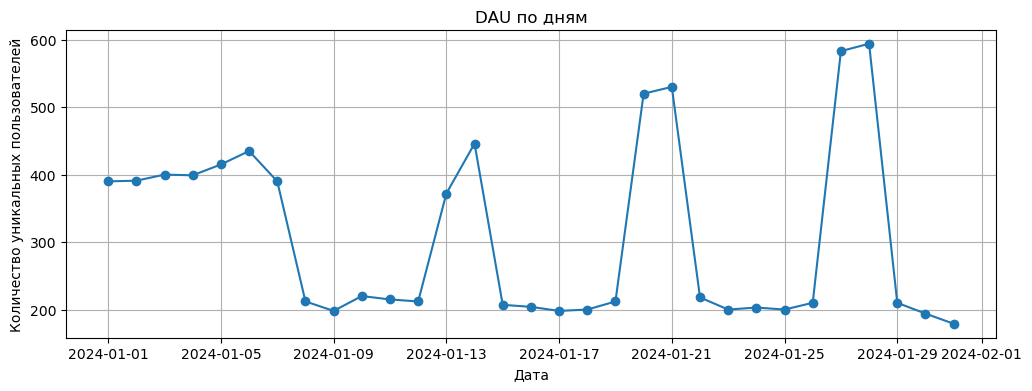

In [7]:
plt.figure(figsize=(12, 4))
plt.plot(dau['date'], dau['DAU'], marker='o')
plt.title('DAU по дням')
plt.xlabel('Дата')
plt.ylabel('Количество уникальных пользователей')
plt.grid(True)
plt.show()

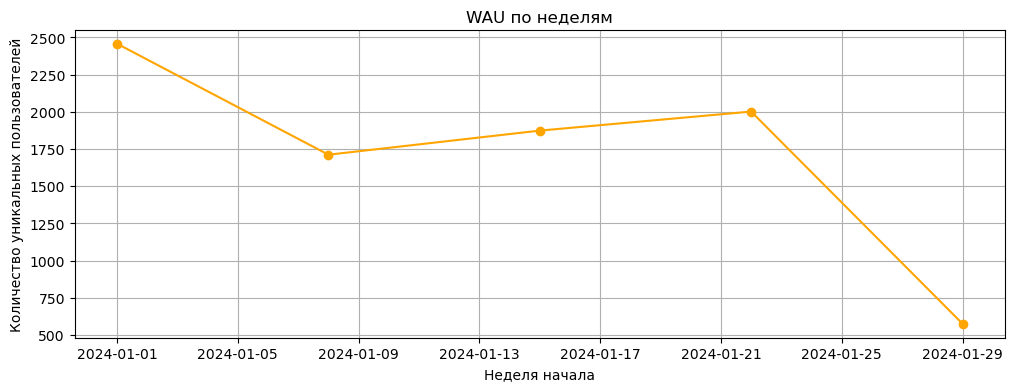

In [8]:
plt.figure(figsize=(12, 4))
plt.plot(wau['week_start_date'], wau['WAU'], marker='o', color='orange')
plt.title('WAU по неделям')
plt.xlabel('Неделя начала')
plt.ylabel('Количество уникальных пользователей')
plt.grid(True)
plt.show()

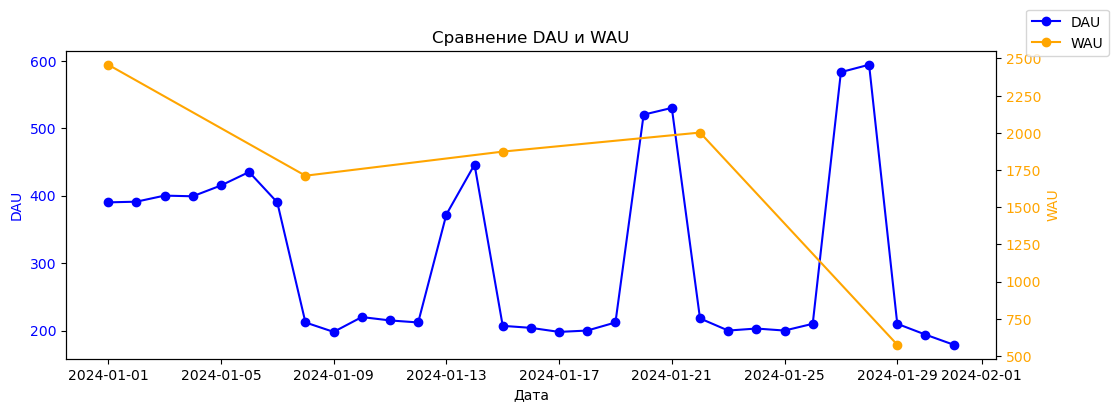

In [9]:
fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.plot(dau['date'], dau['DAU'], label='DAU', color='blue', marker='o')
ax1.set_xlabel('Дата')
ax1.set_ylabel('DAU', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
ax2.plot(wau['week_start_date'], wau['WAU'], label='WAU', color='orange', marker='o')
ax2.set_ylabel('WAU', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

plt.title('Сравнение DAU и WAU')
fig.legend(loc='upper right', bbox_to_anchor=(1, 1))
plt.show()

## Дополнительная задача

Изменятся ли выводы, если поменять определение "активности"? \
В качестве "активности" возьмите действие play (то есть остальные действия не считаются за "клиентскую активность", в отличие от Задачи-3)

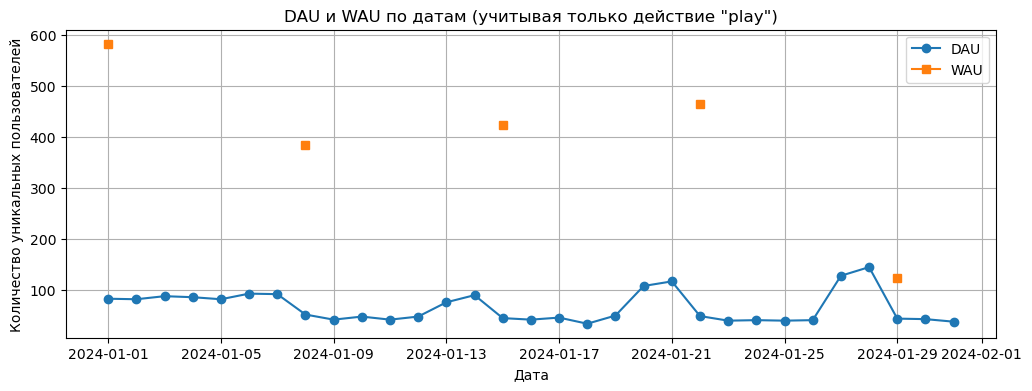

In [10]:
df_play = df_final[df_final['event'] == 'play'].copy()


df_play.loc[:, 'dtime_event'] = pd.to_datetime(df_play['dtime_event'])


dau = df_play.groupby('dtime_event')['id_client'].nunique().reset_index()
dau.columns = ['date', 'DAU']


df_play.loc[:, 'iso_year'] = df_play['dtime_event'].dt.isocalendar().year
df_play.loc[:, 'iso_week'] = df_play['dtime_event'].dt.isocalendar().week

wau = df_play.groupby(['iso_year', 'iso_week'])['id_client'].nunique().reset_index()
wau.columns = ['iso_year', 'iso_week', 'WAU']
wau['week_start_date'] = pd.to_datetime(
    wau['iso_year'].astype(str) + '-W' + wau['iso_week'].astype(str).str.zfill(2) + '-1',
    format='%G-W%V-%u'
)


wau = wau.rename(columns={'week_start_date': 'date'})
df_combined = pd.merge(dau, wau[['date', 'WAU']], on='date', how='outer')


plt.figure(figsize=(12, 4))
plt.plot(df_combined['date'], df_combined['DAU'], label='DAU', marker='o')
plt.plot(df_combined['date'], df_combined['WAU'], label='WAU', marker='s')
plt.title('DAU и WAU по датам (учитывая только действие "play")')
plt.xlabel('Дата')
plt.ylabel('Количество уникальных пользователей')
plt.legend()
plt.grid(True)
plt.show()